# 📊 Analyse & Benchmarking du Moteur de Planning Action

Ce notebook permet de :
- Tester l'algorithme avec différents scénarios
- Visualiser les plannings générés
- Analyser les performances (taux d'assignation, équilibrage)
- Comparer des configurations d'employés

In [6]:
import sys
sys.path.insert(0, '../backend')

from services.moteur import generer_planning, hms
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

plt.style.use('dark_background')
print('✅ Imports OK')

✅ Imports OK


## 1. Scénario de base

In [7]:
charrettes = [
    {'barcode': 'C001', 'duration_min': 45, 'priorite': 1},
    {'barcode': 'C002', 'duration_min': 30, 'priorite': 2},
    {'barcode': 'C003', 'duration_min': 60, 'priorite': 2},
    {'barcode': 'C004', 'duration_min': 20, 'priorite': 3},
    {'barcode': 'C005', 'duration_min': 90, 'priorite': 1},
    {'barcode': 'C006', 'duration_min': 15, 'priorite': 2},
]

employes = [
    {'nom': 'Alice',   'creneaux': [['07:00', '14:00']], 'pauses': [['10:00', '15']]},
    {'nom': 'Bob',     'creneaux': [['09:00', '17:00']], 'pauses': [['12:00', '30']]},
    {'nom': 'Chloé',   'creneaux': [['07:00', '12:00'], ['13:00', '17:00']], 'pauses': []},
]

result = generer_planning(charrettes, employes)

print(f"Taux d'assignation : {result['stats']['taux_assignation']}%")
print(f"Score équilibrage  : {result['stats']['score_equilibrage']}%")
print(f"Non assignées      : {result['non_assignees']}")

df = pd.DataFrame(result['planning'])
df[['employe_nom','barcode','type','tache_duree','debut_str','fin_str']]

Taux d'assignation : 100.0%
Score équilibrage  : 58.8%
Non assignées      : []


,employe_nom,barcode,type,tache_duree,debut_str,fin_str
0,Alice,C001,WORK,45.0,07:00,07:45
1,Alice,C005 (Part 1),WORK (Part 1),13.0,07:47,08:00
2,Alice,PAUSE,PAUSE OBLIGATOIRE,60.0,08:00,09:00
3,Alice,PAUSE,PAUSE FIXE,15.0,10:00,10:15
4,Bob,C006,WORK,15.0,09:00,09:15
5,Bob,C002,WORK,30.0,09:17,09:47
6,Bob,C004,WORK,20.0,09:49,10:09
7,Bob,PAUSE,PAUSE FIXE,30.0,12:00,12:30
8,Chloé,C003,WORK,60.0,07:00,08:00
9,Chloé,PAUSE,PAUSE OBLIGATOIRE,60.0,08:00,09:00


## 2. Visualisation Gantt

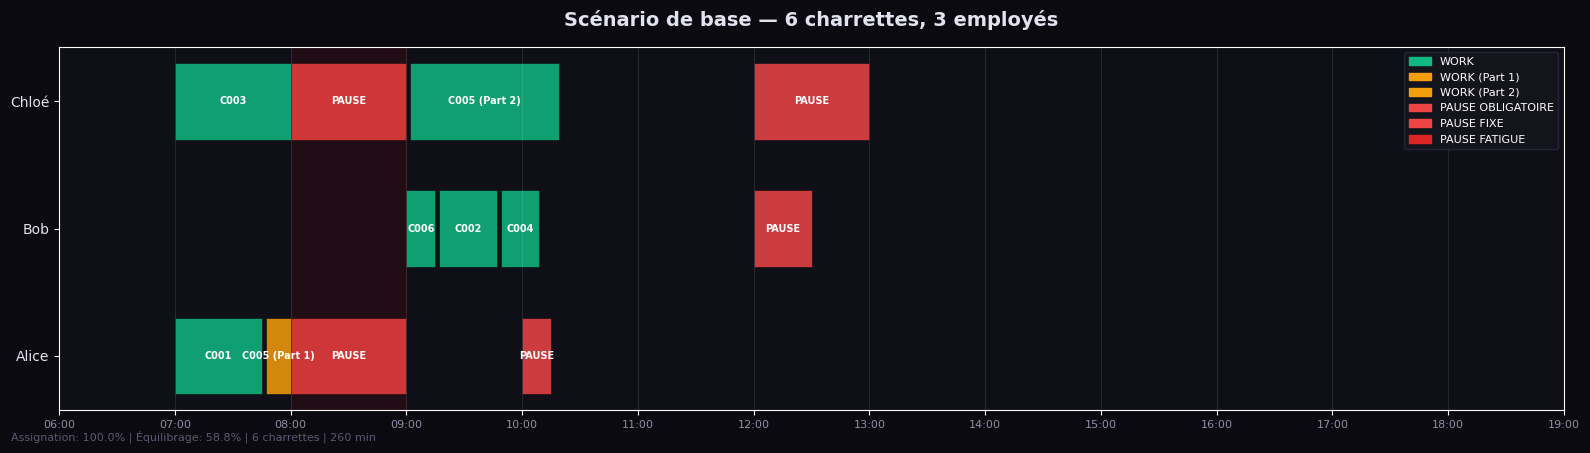

In [8]:
def plot_gantt(result, title='Planning Journalier'):
    df = pd.DataFrame(result['planning'])
    employes = df['employe_nom'].unique()
    colors = {'WORK': '#10b981', 'WORK (Part 1)': '#f59e0b', 'WORK (Part 2)': '#f59e0b',
              'PAUSE OBLIGATOIRE': '#ef4444', 'PAUSE FIXE': '#ef4444', 'PAUSE FATIGUE': '#dc2626'}

    fig, ax = plt.subplots(figsize=(16, max(4, len(employes) * 1.5)))
    ax.set_facecolor('#0f0f18')
    fig.patch.set_facecolor('#0a0a10')

    for y, emp in enumerate(employes):
        taches_emp = df[df['employe_nom'] == emp]
        for _, t in taches_emp.iterrows():
            color = colors.get(t['type'], '#3b82f6')
            ax.barh(y, t['fin'] - t['debut'], left=t['debut'],
                    color=color, alpha=0.85, height=0.6, edgecolor='#0a0a10', linewidth=0.5)
            mid = (t['debut'] + t['fin']) / 2
            if t['fin'] - t['debut'] > 0.15:
                ax.text(mid, y, t['barcode'], ha='center', va='center',
                        fontsize=7, color='white', fontweight='bold')

    # Ligne 8h-9h
    ax.axvspan(8, 9, alpha=0.08, color='red', label='Coupure 8h-9h')

    ax.set_yticks(range(len(employes)))
    ax.set_yticklabels(employes, color='#e2e2f0', fontsize=10)
    ax.set_xlim(6, 19)
    ax.set_xticks(range(6, 20))
    ax.set_xticklabels([f'{h:02d}:00' for h in range(6, 20)], color='#9090a8', fontsize=8)
    ax.grid(axis='x', alpha=0.1, color='white')
    ax.set_title(title, color='#e2e2f0', fontsize=14, fontweight='bold', pad=15)

    legend = [mpatches.Patch(color=c, label=l) for l, c in colors.items()]
    ax.legend(handles=legend, loc='upper right', fontsize=8,
              facecolor='#16161f', edgecolor='#2a2a3e', labelcolor='white')

    stats = result['stats']
    fig.text(0.01, 0.01,
             f"Assignation: {stats['taux_assignation']}% | Équilibrage: {stats['score_equilibrage']}% | "
             f"{stats['total_charrettes']} charrettes | {stats['total_minutes']} min",
             color='#5a5a72', fontsize=8)

    plt.tight_layout()
    plt.show()

plot_gantt(result, 'Scénario de base — 6 charrettes, 3 employés')

## 3. Test des nouvelles contraintes

Avertissements: []
Non assignées : []
Taux          : 100.0%


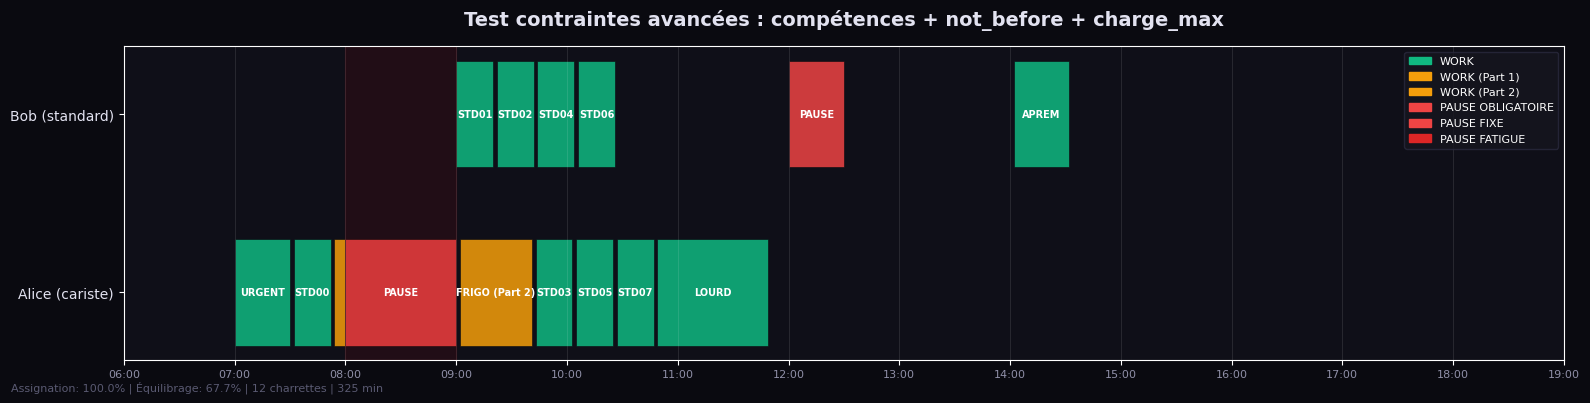

In [9]:
# Test contrainte 'not_before' et compétences
charrettes_avancees = [
    {'barcode': 'URGENT', 'duration_min': 30, 'priorite': 1, 'not_before': None},
    {'barcode': 'FRIGO',  'duration_min': 45, 'priorite': 1, 'competences_requises': ['lourd']},
    {'barcode': 'LOURD',  'duration_min': 60, 'priorite': 2, 'competences_requises': ['lourd']},
    {'barcode': 'APREM',  'duration_min': 30, 'priorite': 2, 'not_before': '14:00'},
    *[{'barcode': f'STD{i:02d}', 'duration_min': 20, 'priorite': 2} for i in range(8)],
]

employes_avances = [
    {'nom': 'Alice (cariste)', 'creneaux': [['07:00', '15:00']], 'pauses': [],
     'competences': ['lourd', 'fragile'], 'charge_max_min': 420},
    {'nom': 'Bob (standard)',  'creneaux': [['09:00', '18:00']], 'pauses': [['12:00', '30']],
     'competences': [], 'charge_max_min': 480},
]

result2 = generer_planning(charrettes_avancees, employes_avances)

print('Avertissements:', result2['avertissements'])
print('Non assignées :', result2['non_assignees'])
print(f"Taux          : {result2['stats']['taux_assignation']}%")

plot_gantt(result2, 'Test contraintes avancées : compétences + not_before + charge_max')

## 4. Benchmark : impact du nombre d'employés

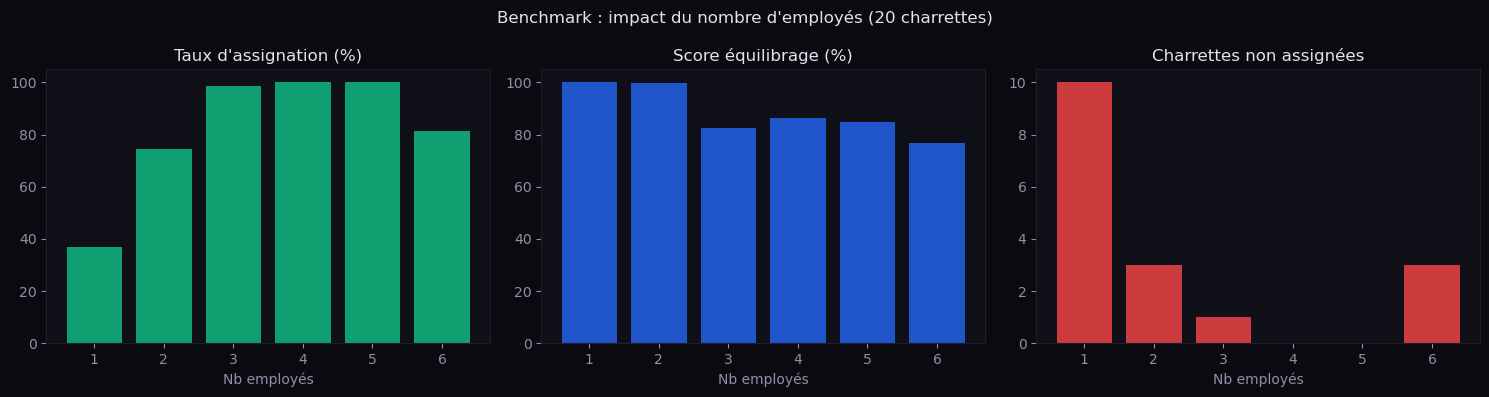

 nb_employes  taux  equilibrage  non_assignees
           1  36.8        100.0             10
           2  74.4         99.6              3
           3  98.7         82.4              1
           4 100.0         86.5              0
           5 100.0         85.0              0
           6  81.2         76.8              3


In [10]:
import random
random.seed(42)

# Générer 20 charrettes aléatoires
charrettes_bench = [
    {'barcode': f'B{i:03d}', 'duration_min': random.randint(15, 90), 'priorite': random.choice([1,2,2,3])}
    for i in range(20)
]

# Tester avec 1 à 6 employés
employe_template = {'creneaux': [['07:00', '15:00']], 'pauses': [['10:00', '15']]}
noms = ['Alice','Bob','Chloé','David','Emma','Flo']

resultats_bench = []
for n in range(1, 7):
    emps = [{**employe_template, 'nom': noms[i]} for i in range(n)]
    r = generer_planning(charrettes_bench, emps)
    resultats_bench.append({
        'nb_employes': n,
        'taux': r['stats']['taux_assignation'],
        'equilibrage': r['stats']['score_equilibrage'],
        'non_assignees': len(r['non_assignees']),
    })

df_bench = pd.DataFrame(resultats_bench)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.patch.set_facecolor('#0a0a10')
for ax in axes:
    ax.set_facecolor('#0f0f18')
    ax.tick_params(colors='#9090a8')
    for spine in ax.spines.values():
        spine.set_edgecolor('#1e1e2e')

axes[0].bar(df_bench['nb_employes'], df_bench['taux'], color='#10b981', alpha=0.85)
axes[0].set_title("Taux d'assignation (%)", color='#e2e2f0')
axes[0].set_xlabel('Nb employés', color='#9090a8')

axes[1].bar(df_bench['nb_employes'], df_bench['equilibrage'], color='#2563eb', alpha=0.85)
axes[1].set_title('Score équilibrage (%)', color='#e2e2f0')
axes[1].set_xlabel('Nb employés', color='#9090a8')

axes[2].bar(df_bench['nb_employes'], df_bench['non_assignees'], color='#ef4444', alpha=0.85)
axes[2].set_title('Charrettes non assignées', color='#e2e2f0')
axes[2].set_xlabel('Nb employés', color='#9090a8')

plt.suptitle('Benchmark : impact du nombre d\'employés (20 charrettes)', color='#e2e2f0', fontsize=12)
plt.tight_layout()
plt.show()

print(df_bench.to_string(index=False))